In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
df_deep = pd.read_csv('Results/perf_benchmark.csv')
df_csp = pd.read_csv('Results/accuracy_per_subject_offline.csv')
df_deep.sort_values(by='subject', inplace=True)
df_csp.sort_values(by='subject', inplace=True)
df_csp["subject"] = np.arange(len(df_csp['subject']))
df = df_deep.merge(df_csp, on='subject', how='left')
df["accuracy_CSP_LDA"] = df["accuracy"]

In [3]:
inline_accuracy = [84.375, 55.625, 98.125, 51.25, 51.25, 65.625, 47.5, 56.225, 66.25, 82.5, 51.875, 60, 65, 49.375,
                   75.625, 49.375, 45.625, 82.5, 98.125, 83.125, 56.875, 88.75, 51.875, 93.125, 81.25, 65.625, 45.625,
                   48.125, 52.5, 40.625, 52.5, 55.5, 62.5, 48.125, 90.625, 70, 47.5, 62.5, 81.25, 49.0625, 51.875,
                   51.875, 55, 56.25, 54.375, 54.375, 46.25, 56.625, 55, 52.5, 64.375, 88.75, 46.25, 47.5, 91.875,
                   99.375, 48.75, 66.25, 60, 56.25, 84.375, 90.625, 60, 50, 82.5, 58.75, 51.875, 55, 60.625, 55.625,
                   47.5, 44.375, 86.25, 68.125, 71.875, 80.625, 53.75, 55, 97.5, 49.375, 55, 49.375, 44.375, 76.25,
                   80.625, 62.5, 73.125]

inline_order = ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9", "A10", "A11", "A12", "A13", "A14", "A15", "A16",
                "A17", "A18", "A19", "A20", "A21", "A22", "A23", "A24", "A25", "A26", "A27", "A28", "A29", "A30", "A31",
                "A32", "A33", "A34", "A35", "A36", "A37", "A38", "A39", "A40", "A41", "A42", "A43", "A44", "A45", "A46",
                "A47", "A48", "A49", "A50", "A51", "A52", "A53", "A54", "A55", "A56", "A57", "A58", "A59", "A60", "B61",
                "B62", "B63", "B64", "B65", "B66", "B67", "B68", "B69", "B70", "B71", "B72", "B73", "B74", "B75", "B76",
                "B77", "B78", "B79", "B80", "B81", "C82", "C83", "C84", "C85", "C86", "C87"]

offline_order = ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9", "A10", "A11", "A12", "A13", "A14", "A15", "A16",
                 "A17", "A18", "A19", "A20", "A21", "A22", "A23", "A24", "A25", "A26", "A27", "A28", "A29", "A30",
                 "A31",
                 "A32", "A33", "A34", "A35", "A36", "A37", "A38", "A39", "A40", "A41", "A42", "A43", "A44", "A45",
                 "A46",
                 "A47", "A48", "A49", "A50", "A51", "A52", "A53", "A54", "A55", "A56", "A57", "A58", "A59", "A60",
                 "B61",
                 "B62", "B63", "B64", "B65", "B66", "B67", "B68", "B69", "B70", "B71", "B72", "B73", "B74", "B75",
                 "B76",
                 "B77", "B78", "B79", "B80", "B81", "C82", "C83", "C84", "C85", "C86", "C87"]

inline_results = pd.DataFrame(inline_accuracy, inline_order, columns=["inline"])
inline_results = inline_results / 100

inline_results = inline_results.sort_index()
df = df_deep.sort_values(
    "subject")  # Sort the index in order to be sure that the performances are correctly affected to the subject
offline_order.sort()

# change df index to match inline index
df["index"] = offline_order
df = df.set_index("index")
df["online_csp"] = inline_results["inline"]

In [4]:
df.mean()

subject                  43.000000
accuracy_Deep4Net_0_4     0.868206
accuracy_Deep4Net         0.761109
online_csp                0.633539
dtype: float64

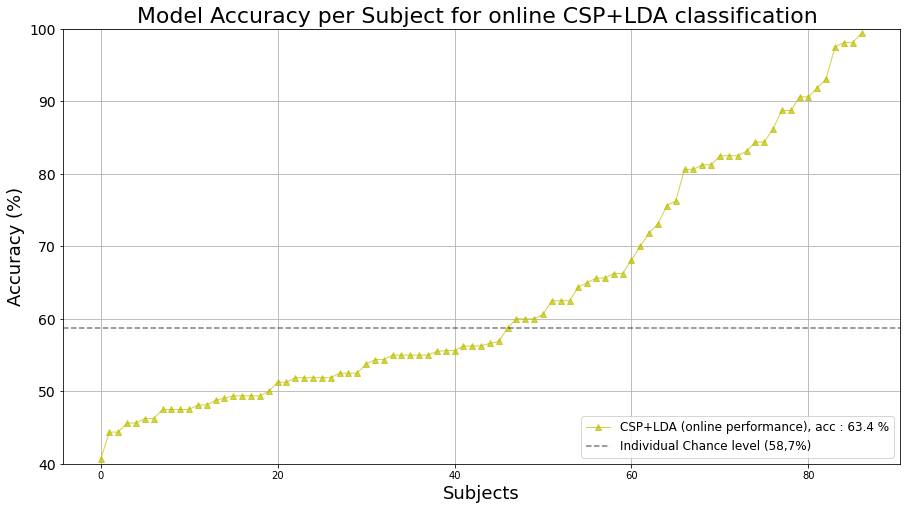

In [10]:

df.sort_values(by='online_csp', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

# Example code assuming df is your DataFrame and contains the required columns
plt.figure(figsize=(15, 8))


# Deep ConvNet 0.5-4.5s
# plt.plot(df.index, df['accuracy_Deep4Net'], 'bs--',  label='Deep ConvNet epoched 0.5- 4.5s acc : {:.1f} %'.format(df['accuracy_Deep4Net'].mean() * 100),alpha=0.7)
# plt.plot(df.index, df['accuracy_Deep4Net'], 'bs--',  label='Deep ConvNet (offline performance) acc : {:.1f} %'.format(df['accuracy_Deep4Net'].mean() * 100),alpha=0.7)

# Deep ConvNet 0-4s
# plt.plot(df.index, df['accuracy_Deep4Net_0_4'], 'rs--',  label='Deep ConvNet epoched 0 - 4s, acc : {:.1f} %'.format(df['accuracy_Deep4Net_0_4'].mean() * 100), alpha=0.7)

# Optional: CSP+LDA (if you have this data)
if 'online_csp' in df.columns:
    # plt.plot(df.index, df['online_csp'], 'y^-', linewidth=1, label='CSP+LDA, acc : {:.1f} %'.format(df['online_csp'].mean() * 100), alpha=0.7)
    plt.plot(df.index, df['online_csp'], 'y^-', linewidth=1, label='CSP+LDA (online performance), acc : {:.1f} %'.format(df['online_csp'].mean() * 100), alpha=0.7)
#plot a vertical line at y=0.5

plt.axhline(y=0.587, alpha=0.5, color='k', linestyle='--', label='Individual Chance level (58,7%)')
# Labels and formatting

plt.xlabel('Subjects', fontsize=18)
plt.yticks(np.arange(0.4,1.01,0.1), np.arange(40,101,10), fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Accuracy (%)',  fontsize=18)
plt.title('Model Accuracy per Subject for online CSP+LDA classification ',  fontsize=22)
plt.legend(  fontsize=12, loc='lower right')
plt.ylim(0.4, 1)
plt.grid(True)

plt.savefig("Results/model_acc_deep.png", dpi=300)
plt.show()


In [6]:
df.sort_values(by='accuracy_CSP_LDA', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

KeyError: 'accuracy_CSP_LDA'

In [ ]:
df.index

In [28]:
# statistical test to compare the two models

t_stat, p_value = stats.ttest_rel(df['accuracy_Deep4Net'], df['accuracy_Deep4Net_0_4'], axis=0)

In [29]:
print("t-statistic:", t_stat, "p-value:", p_value)

t-statistic: -9.609095760500422 p-value: 2.8324972156232844e-15


In [19]:
df['accuracy_Deep4Net'].values

array([0.9125    , 0.8625    , 0.7375    , 0.95625   , 0.71875   ,
       0.68125   , 0.8625    , 0.75625   , 0.95      , 0.8375    ,
       0.81875   , 0.80625   , 0.91875   , 0.76875   , 0.70625   ,
       0.8625    , 0.85      , 0.9       , 0.80625   , 0.75625   ,
       0.775     , 0.85625   , 0.6375    , 0.84375   , 0.75625   ,
       0.8375    , 0.73125   , 0.73125   , 0.66875   , 0.675     ,
       0.675     , 0.7875    , 0.78125   , 0.88125   , 0.98125   ,
       0.625     , 0.825     , 0.78125   , 0.82894737, 0.85625   ,
       0.65625   , 0.775     , 0.65      , 0.6875    , 0.81875   ,
       0.60625   , 0.88125   , 0.775     , 0.775     , 0.6625    ,
       0.66875   , 0.54375   , 0.65625   , 0.7625    , 0.65      ,
       0.75625   , 0.89375   , 0.64375   , 0.78125   , 0.7       ,
       0.6875    , 0.68125   , 0.74375   , 0.6875    , 0.60625   ,
       0.94375   , 0.8375    , 0.85625   , 0.8125    , 0.8375    ,
       0.625     , 0.6125    , 0.63125   , 0.675     , 0.65625